# Vaidya — Layer 1: Cleaning, Formatting & Splitting

Steps covered:
- 1.3 Clean: drop nulls, strip HTML, deduplicate
- 1.4 Instruction format: ChatML with system/user/assistant roles
- 1.5 Stratified 80/10/10 train/val/test split → save as Parquet → push to S3
- 1.8 Data quality report

**Local:** uses the `vaidya` AWS named profile (`~/.aws/credentials`).  
**Kaggle:** add `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_DEFAULT_REGION` as Kaggle secrets.

## Setup

In [4]:
import sys, subprocess

IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in __import__('os').environ

if IN_COLAB or IN_KAGGLE:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'datasets', 'pandas', 'pyarrow', 'scikit-learn', 'awscli', 'boto3'], check=True)
else:
    # Running locally — expects the 'vaidya' conda env
    # conda activate vaidya && jupyter notebook
    import datasets, pandas, sklearn   # will ImportError fast if wrong kernel
    print(f"Local env OK  |  datasets {datasets.__version__}  pandas {pandas.__version__}")

Local env OK  |  datasets 5.0.1  pandas 2.3.3


In [5]:
import os, re, html, time
import pandas as pd
from sklearn.model_selection import train_test_split
pd.set_option('display.max_colwidth', 200)
os.makedirs('../data', exist_ok=True)
print("pandas + sklearn OK")

pandas + sklearn OK


In [6]:
t = time.time()
import matplotlib.pyplot as plt        # slow first time — builds font cache
print(f"matplotlib OK  ({time.time()-t:.1f}s)")

matplotlib OK  (0.5s)


In [7]:
t = time.time()
from datasets import load_dataset     # loads pyarrow, fsspec, huggingface_hub
print(f"datasets OK  ({time.time()-t:.1f}s)")

datasets OK  (0.0s)


In [8]:
import os

# Local: use the 'vaidya' named profile from ~/.aws/credentials
# Kaggle: pull creds from Kaggle secrets instead
IS_KAGGLE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None

if IS_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    _s = UserSecretsClient()
    os.environ['AWS_ACCESS_KEY_ID']     = _s.get_secret('AWS_ACCESS_KEY_ID')
    os.environ['AWS_SECRET_ACCESS_KEY'] = _s.get_secret('AWS_SECRET_ACCESS_KEY')
    os.environ['AWS_DEFAULT_REGION']    = _s.get_secret('AWS_DEFAULT_REGION')
else:
    os.environ['AWS_PROFILE'] = 'vaidya'

S3_BUCKET = 's3://vaidya-artifacts'
DATA_DIR  = '../data'

## 1.3 Load & Clean

In [9]:
ds = load_dataset("openlifescienceai/medmcqa")
raw_df = ds['train'].to_pandas()
print(f"Raw train rows: {len(raw_df):,}")

Raw train rows: 182,822


In [10]:
df = raw_df.copy()

# Keep only single-answer questions
df = df[df['choice_type'] == 'single'].copy()
print(f"After keeping single-choice: {len(df):,}")

# Drop rows with null in required fields
required = ['question', 'opa', 'opb', 'opc', 'opd', 'cop', 'subject_name']
before   = len(df)
df = df.dropna(subset=required)
print(f"After dropping nulls: {len(df):,}  (dropped {before - len(df):,})")

After keeping single-choice: 120,765
After dropping nulls: 120,765  (dropped 0)


In [11]:
def clean_text(s: str) -> str:
    """Strip HTML entities and normalize whitespace."""
    if not isinstance(s, str):
        return s
    s = html.unescape(s)           # &amp; &lt; etc.
    s = re.sub(r'<[^>]+>', '', s)  # leftover HTML tags
    s = re.sub(r'\s+', ' ', s).strip()
    return s

text_cols = ['question', 'opa', 'opb', 'opc', 'opd', 'exp']
for col in text_cols:
    df[col] = df[col].apply(clean_text)

# Normalize subject names (lowercase, strip)
df['subject_name'] = df['subject_name'].str.lower().str.strip()

print("Text cleaning done.")

Text cleaning done.


In [12]:
# Deduplicate on exact question text
before_dedup = len(df)
df = df.drop_duplicates(subset='question', keep='first')
dup_rate = (before_dedup - len(df)) / before_dedup

print(f"Before dedup : {before_dedup:,}")
print(f"After  dedup : {len(df):,}")
print(f"Duplicate rate: {dup_rate:.2%}")

Before dedup : 120,765
After  dedup : 120,705
Duplicate rate: 0.05%


In [13]:
# Validate cop range
assert df['cop'].between(0, 3).all(), "cop has values outside 0–3!"
df['cop'] = df['cop'].astype(int)
print("cop column validated: all values in {0, 1, 2, 3}")

cop column validated: all values in {0, 1, 2, 3}


## 1.4 Instruction Formatting (ChatML)

In [14]:
COP_TO_LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
COP_TO_COL   = {0: 'opa', 1: 'opb', 2: 'opc', 3: 'opd'}

SYSTEM_PROMPT = (
    "You are Vaidya, an expert in Indian medical licensing exams (AIIMS, PGI, USMLE-equivalent). "
    "Answer the question by selecting the single best option."
)

def format_chatml(row: pd.Series) -> str:
    label     = COP_TO_LABEL[row['cop']]
    opt_text  = row[COP_TO_COL[row['cop']]]
    exp_part  = f" {row['exp']}" if pd.notna(row['exp']) and str(row['exp']).strip() else ""

    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n"
        f"Question: {row['question']}\n\n"
        f"Options:\n"
        f"A. {row['opa']}\n"
        f"B. {row['opb']}\n"
        f"C. {row['opc']}\n"
        f"D. {row['opd']}<|im_end|>\n"
        f"<|im_start|>assistant\n"
        f"The correct answer is {label}. {opt_text}.{exp_part}<|im_end|>"
    )

df['text'] = df.apply(format_chatml, axis=1)
print(f"Formatted {len(df):,} rows.")
print("\n--- Sample output ---")
print(df['text'].iloc[0])

Formatted 120,705 rows.

--- Sample output ---
<|im_start|>system
You are Vaidya, an expert in Indian medical licensing exams (AIIMS, PGI, USMLE-equivalent). Answer the question by selecting the single best option.<|im_end|>
<|im_start|>user
Question: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma

Options:
A. Hyperplasia
B. Hyperophy
C. Atrophy
D. Dyplasia<|im_end|>
<|im_start|>assistant
The correct answer is C. Atrophy. Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uterine prolapse or functional disorders cause hydronephrosis which by definition is used to describe dilatation of renal pelvis and calculus associated with progressive atrophy of the kidney due to obstruction to the outflow of urine Refer Robbins 7yh/9,1012,9/e. P950<|im_end|>


## 1.5 Stratified 80/10/10 Split

In [15]:
# Some subjects may have very few samples and can't be stratified — group them
subject_counts = df['subject_name'].value_counts()
rare_subjects  = subject_counts[subject_counts < 20].index
df['subject_strat'] = df['subject_name'].apply(
    lambda s: '__rare__' if s in rare_subjects else s
)
print(f"Subjects with < 20 samples grouped as '__rare__': {len(rare_subjects)}")

Subjects with < 20 samples grouped as '__rare__': 0


In [16]:
# First split off 20% (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['subject_strat']
)

# Split the 20% into equal val and test (10% each)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['subject_strat']
)

print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")
print(f"Test  : {len(test_df):,}")
print(f"Total : {len(train_df) + len(val_df) + len(test_df):,}")

Train : 96,564
Val   : 12,070
Test  : 12,071
Total : 120,705


In [17]:
# Verify subject distribution is consistent across splits
top10 = subject_counts.head(10).index
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    pct = split_df['subject_name'].value_counts(normalize=True)[top10] * 100
    print(f"\n{split_name} — top 10 subject %:")
    print(pct.round(1).to_string())


train — top 10 subject %:
subject_name
medicine                        9.0
surgery                         8.8
pathology                       8.2
pharmacology                    7.8
anatomy                         7.7
social & preventive medicine    6.7
microbiology                    6.3
gynaecology & obstetrics        5.3
physiology                      5.2
biochemistry                    5.0

val — top 10 subject %:
subject_name
medicine                        9.0
surgery                         8.8
pathology                       8.2
pharmacology                    7.8
anatomy                         7.6
social & preventive medicine    6.7
microbiology                    6.3
gynaecology & obstetrics        5.3
physiology                      5.1
biochemistry                    4.9

test — top 10 subject %:
subject_name
medicine                        9.0
surgery                         8.8
pathology                       8.2
pharmacology                    7.8
anatomy            

In [18]:
# Select columns to save
save_cols = ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'subject_name', 'exp', 'text']

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    out_path = f'{DATA_DIR}/{split_name}.parquet'
    split_df[save_cols].to_parquet(out_path, index=False)
    print(f"Saved: {out_path}  ({len(split_df):,} rows)")

Saved: ../data/train.parquet  (96,564 rows)
Saved: ../data/val.parquet  (12,070 rows)
Saved: ../data/test.parquet  (12,071 rows)


## Push to S3

In [19]:
!aws s3 sync {DATA_DIR}/ {S3_BUCKET}/data/ --exclude "*" --include "*.parquet"
print("Data pushed to S3.")

Completed 1.0 MiB/94.1 MiB (9.6 MiB/s) with 3 file(s) remaining
Completed 2.0 MiB/94.1 MiB (12.5 MiB/s) with 3 file(s) remaining
Completed 3.0 MiB/94.1 MiB (15.4 MiB/s) with 3 file(s) remaining
Completed 4.0 MiB/94.1 MiB (19.4 MiB/s) with 3 file(s) remaining
Completed 5.0 MiB/94.1 MiB (19.0 MiB/s) with 3 file(s) remaining
Completed 6.0 MiB/94.1 MiB (21.7 MiB/s) with 3 file(s) remaining
Completed 7.0 MiB/94.1 MiB (25.0 MiB/s) with 3 file(s) remaining
Completed 8.0 MiB/94.1 MiB (27.4 MiB/s) with 3 file(s) remaining
Completed 9.0 MiB/94.1 MiB (13.9 MiB/s) with 3 file(s) remaining
Completed 10.0 MiB/94.1 MiB (14.4 MiB/s) with 3 file(s) remaining
Completed 10.5 MiB/94.1 MiB (13.7 MiB/s) with 3 file(s) remaining
Completed 11.2 MiB/94.1 MiB (14.3 MiB/s) with 3 file(s) remaining
Completed 12.2 MiB/94.1 MiB (14.3 MiB/s) with 3 file(s) remaining
Completed 13.2 MiB/94.1 MiB (15.3 MiB/s) with 3 file(s) remaining
Completed 14.2 MiB/94.1 MiB (16.3 MiB/s) with 3 file(s) remaining
Completed 15.2 MiB/9

## 1.8 Data Quality Report

In [20]:
# Token length analysis (character proxy — actual tokens in notebook 03)
train_df['text_len_chars'] = train_df['text'].str.len()

stats = train_df['text_len_chars'].describe(percentiles=[0.5, 0.95, 0.99])
print("Text length (chars) stats on train:")
print(stats)

Text length (chars) stats on train:
count    96564.000000
mean       902.337403
std        609.952884
min        319.000000
50%        741.000000
95%       1943.850000
99%       3244.370000
max      22792.000000
Name: text_len_chars, dtype: float64


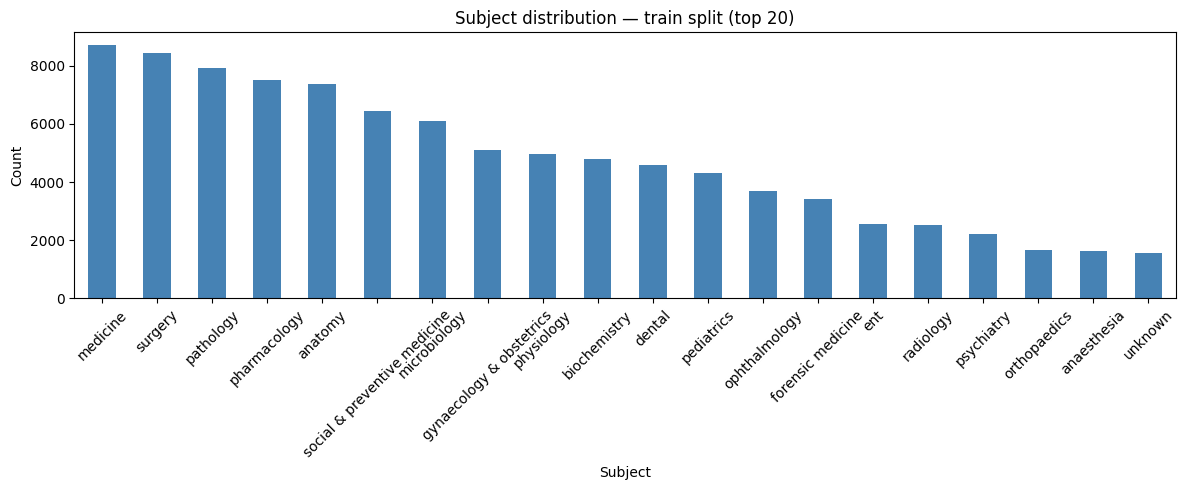

In [21]:
# Subject distribution bar chart
fig, ax = plt.subplots(figsize=(12, 5))
train_df['subject_name'].value_counts().head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Subject distribution — train split (top 20)')
ax.set_xlabel('Subject')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('subject_dist_train.png', dpi=150)
plt.show()

In [22]:
# Write quality report markdown
exp_rate = train_df['exp'].notna().mean()

report = f"""# Vaidya — Layer 1 Data Quality Report

## Dataset: MedMCQA (train split)

| Metric | Value |
|--------|-------|
| Raw rows (all types) | {len(raw_df):,} |
| After single-choice filter | {len(raw_df[raw_df['choice_type']=='single']):,} |
| After null drop | {before_dedup:,} |
| After deduplication | {len(df):,} |
| Duplicate rate | {dup_rate:.2%} |
| Explanation present (train) | {exp_rate:.1%} |
| Unique subjects | {df['subject_name'].nunique()} |

## Split sizes

| Split | Rows |
|-------|------|
| train | {len(train_df):,} |
| val   | {len(val_df):,} |
| test  | {len(test_df):,} |

## Text length (characters)

| Stat | Value |
|------|-------|
| Mean | {stats['mean']:.0f} |
| p50  | {stats['50%']:.0f} |
| p95  | {stats['95%']:.0f} |
| p99  | {stats['99%']:.0f} |
| Max  | {stats['max']:.0f} |

## Gate check

- [ ] train.parquet ≥ 140k rows
- [ ] val.parquet ≥ 17k rows
- [ ] test.parquet ≥ 17k rows
- [ ] Duplicate rate < 1%
- [ ] S3 sync: s3://vaidya-artifacts/data/

_Token length analysis (actual BPE tokens) is in notebook 03._
"""

with open('quality_report.md', 'w') as f:
    f.write(report)

print(report)

# Vaidya — Layer 1 Data Quality Report

## Dataset: MedMCQA (train split)

| Metric | Value |
|--------|-------|
| Raw rows (all types) | 182,822 |
| After single-choice filter | 120,765 |
| After null drop | 120,765 |
| After deduplication | 120,705 |
| Duplicate rate | 0.05% |
| Explanation present (train) | 88.1% |
| Unique subjects | 21 |

## Split sizes

| Split | Rows |
|-------|------|
| train | 96,564 |
| val   | 12,070 |
| test  | 12,071 |

## Text length (characters)

| Stat | Value |
|------|-------|
| Mean | 902 |
| p50  | 741 |
| p95  | 1944 |
| p99  | 3244 |
| Max  | 22792 |

## Gate check

- [ ] train.parquet ≥ 140k rows
- [ ] val.parquet ≥ 17k rows
- [ ] test.parquet ≥ 17k rows
- [ ] Duplicate rate < 1%
- [ ] S3 sync: s3://vaidya-artifacts/data/

_Token length analysis (actual BPE tokens) is in notebook 03._

